In [1]:
import json
import pandas as pd
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def get_json(data): 
    infor = {
        "id": data.get("system:index").iloc[0],
        "date": datetime.utcfromtimestamp(data["system:time_start"].iloc[0]/1000),
        "orbit_pass": data.get("orbitProperties_pass").iloc[0],
        "platform": data.get("platform_number").iloc[0],
        "Instrument": data.get("instrumentMode").iloc[0],
        "resolution": data.get("resolution_meters").iloc[0]
    }

    mean_values = {col.split('.')[-1] : data[col].iloc[0]
                for col in data.columns if col.startswith("features_statistics") and col.endswith("_mean")}

    df = {**infor, **mean_values}

    return df

In [ ]:
sentinel_1 = []
sentinel1_path = "sentinel-1"
years = ["2019", "2020", "2021"]
months = []
years_path = []
img_path = []
for year in years:
    path = os.path.join(sentinel1_path, f"dbscl-sentinel-1-{year}")
    years_path.append(path)

for year_path in years_path:
    for dirs, folders, files in os.walk(year_path):
        for file in files:
            if file.endswith(".json"):
                dir_json = os.path.join(dirs, file)
                with open(dir_json) as f:
                    data = json.load(f)
                data = pd.json_normalize(data)
                data_json = get_json(data)
                sentinel_1.append(data_json)
            
            if file.endswith(".png"):
                img_dir = os.path.join(dirs, file)
                img_path.append(img_dir)

sentinel_1 = pd.DataFrame(sentinel_1)

sentinel_1
                

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10556\1837901422.py:4: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "date": datetime.utcfromtimestamp(data["system:time_start"].iloc[0]/1000),


,id,date,orbit_pass,platform,Instrument,resolution,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean
0,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,2019-01-01 22:45:11,DESCENDING,A,IW,10,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117
1,S1A_IW_GRDH_1SDV_20190101T224536_20190101T2246...,2019-01-01 22:45:36,DESCENDING,A,IW,10,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045
2,S1A_IW_GRDH_1SDV_20190101T224601_20190101T2246...,2019-01-01 22:46:01,DESCENDING,A,IW,10,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158
3,S1A_IW_GRDH_1SDV_20190102T111053_20190102T1111...,2019-01-02 11:10:53,ASCENDING,A,IW,10,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533
4,S1A_IW_GRDH_1SDV_20190102T111122_20190102T1111...,2019-01-02 11:11:22,ASCENDING,A,IW,10,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,S1A_IW_GRDH_1SDV_20211228T224529_20211228T2245...,2021-12-28 22:45:29,DESCENDING,A,IW,10,-13.262261,7.734260,-0.303824,171.194891,2.607649,-26.524521,1.891253,-17.129390,0.546314,-9.395131,38.105695
1281,S1A_IW_GRDH_1SDV_20211228T224554_20211228T2246...,2021-12-28 22:45:54,DESCENDING,A,IW,10,-12.777369,7.573029,-0.306890,157.396961,2.613781,-25.554738,2.121927,-16.563883,0.536995,-8.990854,38.756687
1282,S1A_IW_GRDH_1SDV_20211228T224619_20211228T2246...,2021-12-28 22:46:19,DESCENDING,A,IW,10,-13.847672,7.338150,-0.276040,184.714374,2.552080,-27.695344,1.652758,-17.516747,0.569646,-10.178597,41.011031
1283,S1A_IW_GRDH_1SDV_20211229T111111_20211229T1111...,2021-12-29 11:11:11,ASCENDING,A,IW,10,-14.028213,7.669149,-0.281880,187.853582,2.563760,-28.056427,1.856888,-17.862788,0.569599,-10.193639,38.569416


In [4]:
rain = pd.read_csv("natural/precipitation/chirps_mekong_delta_2019_2024_full.csv")
rain

,province,date,precipitation
0,Soc Trang,2019-01-01,8.083463
1,Soc Trang,2019-01-02,7.313124
2,Soc Trang,2019-01-03,2.128573
3,Soc Trang,2019-01-04,0.399126
4,Soc Trang,2019-01-05,0.000000
...,...,...,...
28491,Tien Giang,2024-12-27,3.203309
28492,Tien Giang,2024-12-28,1.845928
28493,Tien Giang,2024-12-29,0.000000
28494,Tien Giang,2024-12-30,0.000000


In [5]:
#rain.rename(columns={"date":"time"}, inplace= True)
sentinel_1['date'] = pd.to_datetime(sentinel_1['date']).dt.date
rain['date'] = pd.to_datetime(rain['date']).dt.date
rain_daily = rain.groupby('date', as_index=False)['precipitation'].mean()

sentinel_1_rain = sentinel_1.merge(rain_daily, on=['date'], how='left')

sentinel_1_rain

,id,date,orbit_pass,platform,Instrument,resolution,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation
0,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,2019-01-01,DESCENDING,A,IW,10,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117,5.097843
1,S1A_IW_GRDH_1SDV_20190101T224536_20190101T2246...,2019-01-01,DESCENDING,A,IW,10,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045,5.097843
2,S1A_IW_GRDH_1SDV_20190101T224601_20190101T2246...,2019-01-01,DESCENDING,A,IW,10,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158,5.097843
3,S1A_IW_GRDH_1SDV_20190102T111053_20190102T1111...,2019-01-02,ASCENDING,A,IW,10,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533,9.548983
4,S1A_IW_GRDH_1SDV_20190102T111122_20190102T1111...,2019-01-02,ASCENDING,A,IW,10,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142,9.548983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,S1A_IW_GRDH_1SDV_20211228T224529_20211228T2245...,2021-12-28,DESCENDING,A,IW,10,-13.262261,7.734260,-0.303824,171.194891,2.607649,-26.524521,1.891253,-17.129390,0.546314,-9.395131,38.105695,0.304541
1281,S1A_IW_GRDH_1SDV_20211228T224554_20211228T2246...,2021-12-28,DESCENDING,A,IW,10,-12.777369,7.573029,-0.306890,157.396961,2.613781,-25.554738,2.121927,-16.563883,0.536995,-8.990854,38.756687,0.304541
1282,S1A_IW_GRDH_1SDV_20211228T224619_20211228T2246...,2021-12-28,DESCENDING,A,IW,10,-13.847672,7.338150,-0.276040,184.714374,2.552080,-27.695344,1.652758,-17.516747,0.569646,-10.178597,41.011031,0.304541
1283,S1A_IW_GRDH_1SDV_20211229T111111_20211229T1111...,2021-12-29,ASCENDING,A,IW,10,-14.028213,7.669149,-0.281880,187.853582,2.563760,-28.056427,1.856888,-17.862788,0.569599,-10.193639,38.569416,0.106470


In [6]:
print(sentinel_1_rain.shape)

(1285, 18)


In [7]:
print(sentinel_1_rain.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1285 entries, 0 to 1284
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      1285 non-null   object 
 1   date                    1285 non-null   object 
 2   orbit_pass              1285 non-null   object 
 3   platform                1285 non-null   object 
 4   Instrument              1285 non-null   object 
 5   resolution              1285 non-null   int64  
 6   DPSVI_mean              1285 non-null   float64
 7   Diff_Backscatter_mean   1285 non-null   float64
 8   ND_VV_VH_mean           1285 non-null   float64
 9   Prod_Backscatter_mean   1285 non-null   float64
 10  RVI_mean                1285 non-null   float64
 11  Total_Backscatter_mean  1285 non-null   float64
 12  VH_VV_ratio_mean        1285 non-null   float64
 13  VH_mean                 1285 non-null   float64
 14  VV_VH_ratio_mean        1285 non-null   

In [8]:
print(sentinel_1_rain.isna().sum())

id                        0
date                      0
orbit_pass                0
platform                  0
Instrument                0
resolution                0
DPSVI_mean                0
Diff_Backscatter_mean     0
ND_VV_VH_mean             0
Prod_Backscatter_mean     0
RVI_mean                  0
Total_Backscatter_mean    0
VH_VV_ratio_mean          0
VH_mean                   0
VV_VH_ratio_mean          0
VV_mean                   0
angle_mean                0
precipitation             0
dtype: int64


In [9]:
print(sentinel_1_rain['orbit_pass'].unique())

['DESCENDING' 'ASCENDING']


In [10]:
print(sentinel_1_rain['platform'].unique())

['A' 'B']


In [11]:
print(sentinel_1_rain['Instrument'].unique())

['IW']


In [12]:
print(sentinel_1_rain['resolution'].unique())

[10]


$ 
\text{Features: 'Instrument' and 'resolution' are static} \Rightarrow \ \text{Drop 'Instrument' and 'resolution'}
$

In [13]:
sentinel_1_rain.drop(columns=['Instrument', 'resolution'], axis=1, inplace = True)

In [14]:
sentinel_1_rain

,id,date,orbit_pass,platform,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation
0,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,2019-01-01,DESCENDING,A,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117,5.097843
1,S1A_IW_GRDH_1SDV_20190101T224536_20190101T2246...,2019-01-01,DESCENDING,A,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045,5.097843
2,S1A_IW_GRDH_1SDV_20190101T224601_20190101T2246...,2019-01-01,DESCENDING,A,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158,5.097843
3,S1A_IW_GRDH_1SDV_20190102T111053_20190102T1111...,2019-01-02,ASCENDING,A,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533,9.548983
4,S1A_IW_GRDH_1SDV_20190102T111122_20190102T1111...,2019-01-02,ASCENDING,A,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142,9.548983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,S1A_IW_GRDH_1SDV_20211228T224529_20211228T2245...,2021-12-28,DESCENDING,A,-13.262261,7.734260,-0.303824,171.194891,2.607649,-26.524521,1.891253,-17.129390,0.546314,-9.395131,38.105695,0.304541
1281,S1A_IW_GRDH_1SDV_20211228T224554_20211228T2246...,2021-12-28,DESCENDING,A,-12.777369,7.573029,-0.306890,157.396961,2.613781,-25.554738,2.121927,-16.563883,0.536995,-8.990854,38.756687,0.304541
1282,S1A_IW_GRDH_1SDV_20211228T224619_20211228T2246...,2021-12-28,DESCENDING,A,-13.847672,7.338150,-0.276040,184.714374,2.552080,-27.695344,1.652758,-17.516747,0.569646,-10.178597,41.011031,0.304541
1283,S1A_IW_GRDH_1SDV_20211229T111111_20211229T1111...,2021-12-29,ASCENDING,A,-14.028213,7.669149,-0.281880,187.853582,2.563760,-28.056427,1.856888,-17.862788,0.569599,-10.193639,38.569416,0.106470


# ***DATA OBSERVATION***

In [15]:
columns = ["DPSVI_mean", 
           "Diff_Backscatter_mean", 
           "ND_VV_VH_mean",
           "Prod_Backscatter_mean",
           "RVI_mean",
           "Total_Backscatter_mean",
           "VH_VV_ratio_mean",
           "VH_mean",
           "VV_VH_ratio_mean",
           "VV_mean",
           "angle_mean" ]
for col in columns:
    print(col)
    print(sentinel_1_rain[col].unique())

DPSVI_mean
[-12.82105573 -12.63633523 -13.44170353 ... -13.84767221 -14.02821337
 -13.05255252]
Diff_Backscatter_mean
[6.79840067 6.70152439 6.63060421 ... 7.33815017 7.66914933 7.73220645]
ND_VV_VH_mean
[-0.28749288 -0.25803724 -0.25522716 ... -0.27603994 -0.28187975
 -0.30804868]
Prod_Backscatter_mean
[156.49138982 156.33655536 177.19609827 ... 184.71437359 187.85358178
 164.13648679]
RVI_mean
[2.57498575 2.51607447 2.51045433 ... 2.55207987 2.56375951 2.61609737]
Total_Backscatter_mean
[-25.64211146 -25.27267046 -26.88340706 ... -27.69534443 -28.05642674
 -26.10510503]
VH_VV_ratio_mean
[1.91179866 1.80571103 1.51767494 ... 1.65275765 1.85688849 1.93306528]
VH_mean
[-16.22025607 -15.98709742 -16.75700564 ... -17.5167473  -17.86278803
 -16.91865574]
VV_VH_ratio_mean
[0.58524545 0.57400686 0.59867497 ... 0.56964636 0.56959918 0.53768188]
VV_mean
[ -9.42185539  -9.28557303 -10.12640143 ... -10.17859713 -10.19363871
  -9.18644929]
angle_mean
[37.78011681 38.75204504 41.00515764 ... 41.01

In [16]:
sentinel_1_rain


,id,date,orbit_pass,platform,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation
0,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,2019-01-01,DESCENDING,A,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117,5.097843
1,S1A_IW_GRDH_1SDV_20190101T224536_20190101T2246...,2019-01-01,DESCENDING,A,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045,5.097843
2,S1A_IW_GRDH_1SDV_20190101T224601_20190101T2246...,2019-01-01,DESCENDING,A,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158,5.097843
3,S1A_IW_GRDH_1SDV_20190102T111053_20190102T1111...,2019-01-02,ASCENDING,A,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533,9.548983
4,S1A_IW_GRDH_1SDV_20190102T111122_20190102T1111...,2019-01-02,ASCENDING,A,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142,9.548983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,S1A_IW_GRDH_1SDV_20211228T224529_20211228T2245...,2021-12-28,DESCENDING,A,-13.262261,7.734260,-0.303824,171.194891,2.607649,-26.524521,1.891253,-17.129390,0.546314,-9.395131,38.105695,0.304541
1281,S1A_IW_GRDH_1SDV_20211228T224554_20211228T2246...,2021-12-28,DESCENDING,A,-12.777369,7.573029,-0.306890,157.396961,2.613781,-25.554738,2.121927,-16.563883,0.536995,-8.990854,38.756687,0.304541
1282,S1A_IW_GRDH_1SDV_20211228T224619_20211228T2246...,2021-12-28,DESCENDING,A,-13.847672,7.338150,-0.276040,184.714374,2.552080,-27.695344,1.652758,-17.516747,0.569646,-10.178597,41.011031,0.304541
1283,S1A_IW_GRDH_1SDV_20211229T111111_20211229T1111...,2021-12-29,ASCENDING,A,-14.028213,7.669149,-0.281880,187.853582,2.563760,-28.056427,1.856888,-17.862788,0.569599,-10.193639,38.569416,0.106470


# ***UNIVATIATE ANALYSIS***

<Axes: title={'center': 'Số ảnh theo năm'}, xlabel='year'>

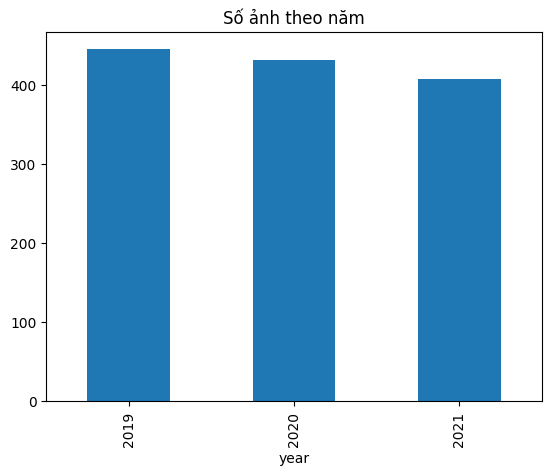

In [17]:
sentinel_1_rain['date'] = pd.to_datetime(sentinel_1_rain['date'])
sentinel_1_rain['year'] = sentinel_1_rain['date'].dt.year
sentinel_1_rain['month'] = sentinel_1_rain['date'].dt.month

sentinel_1_rain['year'].value_counts().sort_index().plot(kind='bar', title='Số ảnh theo năm')


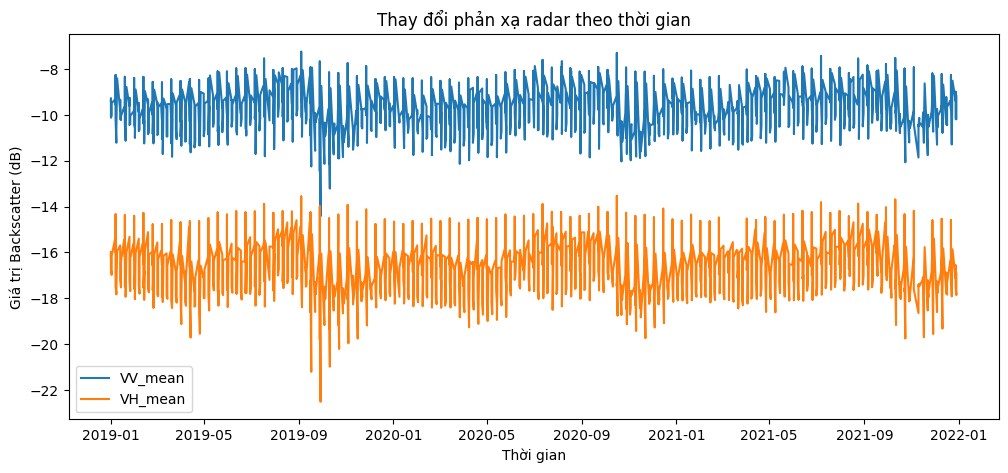

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(sentinel_1_rain['date'], sentinel_1_rain['VV_mean'], label='VV_mean')
plt.plot(sentinel_1_rain['date'], sentinel_1_rain['VH_mean'], label='VH_mean')
plt.legend()
plt.title('Thay đổi phản xạ radar theo thời gian')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị Backscatter (dB)')
plt.show()


$
    \text{Ta thấy mức độ phản xạ VV luôn cao hơn VH} 
    \Rightarrow \text{Phản xạ bề mặt như đất, nước nhạy hơn so với thảm thực vật} \\
    \text{Ta thấy cả VV và VH đều dao động tuần hoàn rõ rệt}
    \Rightarrow \text{Thể hiện sự thay đổi theo mùa vụ} \\
    \text{Khoảng giữa năm 2019–2020 có sự giảm mạnh}
    \Rightarrow \text{Có thể xuất hiện mưa lớn.}
$

$
    \text{Ta thấy mức độ phản xạ VV luôn cao hơn VH} 
    \Rightarrow \text{Phản xạ bề mặt như đất, nước nhạy hơn so với thảm thực vật} \\
    \text{Ta thấy cả VV và VH đều dao động tuần hoàn rõ rệt} 
    \Rightarrow \text{Thể hiện sự thay đổi theo mùa vụ} \\
    \text{Khoảng giữa năm 2019–2020 có sự giảm mạnh} 
    \Rightarrow \text{Có thể xuất hiện mưa lớn.}
$


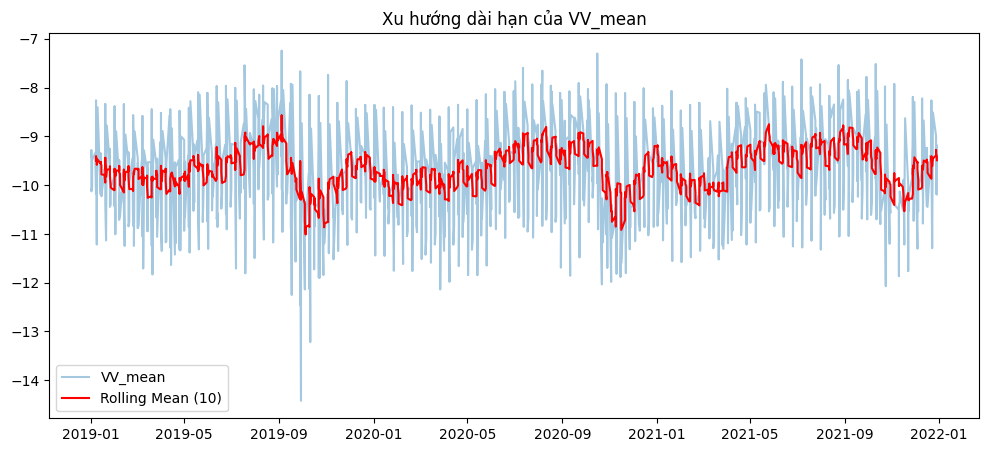

In [19]:
sentinel_1_sorted = sentinel_1_rain.sort_values('date')
sentinel_1_sorted['VV_roll'] = sentinel_1_sorted['VV_mean'].rolling(window=10).mean()
plt.figure(figsize=(12,5))
plt.plot(sentinel_1_sorted['date'], sentinel_1_sorted['VV_mean'], alpha=0.4, label='VV_mean')
plt.plot(sentinel_1_sorted['date'], sentinel_1_sorted['VV_roll'], color='red', label='Rolling Mean (10)')
plt.legend()
plt.title('Xu hướng dài hạn của VV_mean')
plt.show()


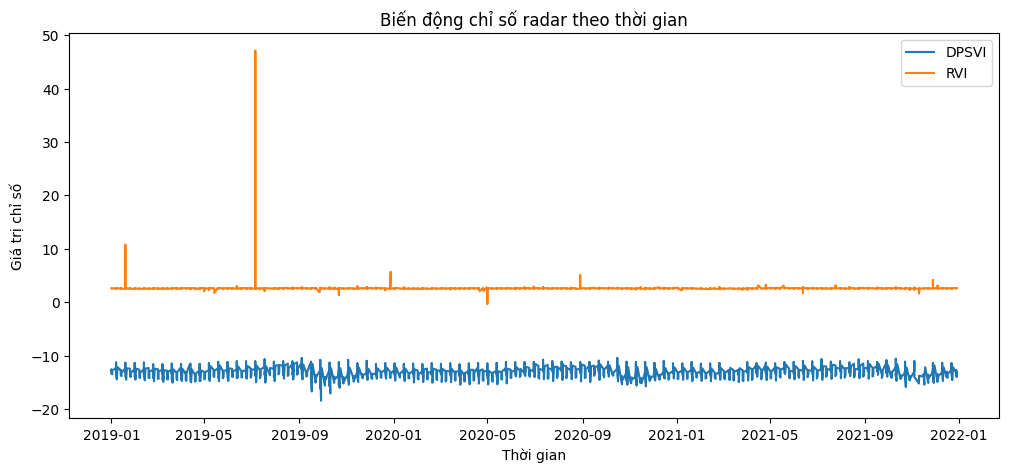

In [20]:
plt.figure(figsize=(12,5))
plt.plot(sentinel_1_rain['date'], sentinel_1_rain['DPSVI_mean'], label='DPSVI')
plt.plot(sentinel_1_rain['date'], sentinel_1_rain['RVI_mean'], label='RVI')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị chỉ số')
plt.title('Biến động chỉ số radar theo thời gian')
plt.legend()
plt.show()


$
    \text{DPSVI và RVI thay dao động đều} \Rightarrow \text{Cho thấy được tính mùa vụ của DPSVI và RVI} \\
    \text{RVI: Thời điểm khoảng 2019_01 có sự tăng nhẹ và tăng mạnh tại thời điểm 2019_05 - 2019_09} \Rightarrow \text{}
$

In [21]:
import cv2, os
import numpy as np

image_features = []

for year_path in years_path:
    for dirs, folders, files in os.walk(year_path):
        for file in files:
            if file.endswith(".png"):
                img_path = os.path.join(dirs, file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                image_features.append({
                    'id': file.split('.')[-1],
                    'img_mean': img.mean(),
                    'img_std': img.std()
                })
img_df = pd.DataFrame(image_features)

df_merged = sentinel_1_rain.merge(img_df, on='id', how='left')
df_merged

,id,date,orbit_pass,platform,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation,year,month,img_mean,img_std
0,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,2019-01-01,DESCENDING,A,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117,5.097843,2019,1,NaN,NaN
1,S1A_IW_GRDH_1SDV_20190101T224536_20190101T2246...,2019-01-01,DESCENDING,A,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045,5.097843,2019,1,NaN,NaN
2,S1A_IW_GRDH_1SDV_20190101T224601_20190101T2246...,2019-01-01,DESCENDING,A,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158,5.097843,2019,1,NaN,NaN
3,S1A_IW_GRDH_1SDV_20190102T111053_20190102T1111...,2019-01-02,ASCENDING,A,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533,9.548983,2019,1,NaN,NaN
4,S1A_IW_GRDH_1SDV_20190102T111122_20190102T1111...,2019-01-02,ASCENDING,A,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142,9.548983,2019,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,S1A_IW_GRDH_1SDV_20211228T224529_20211228T2245...,2021-12-28,DESCENDING,A,-13.262261,7.734260,-0.303824,171.194891,2.607649,-26.524521,1.891253,-17.129390,0.546314,-9.395131,38.105695,0.304541,2021,12,NaN,NaN
1281,S1A_IW_GRDH_1SDV_20211228T224554_20211228T2246...,2021-12-28,DESCENDING,A,-12.777369,7.573029,-0.306890,157.396961,2.613781,-25.554738,2.121927,-16.563883,0.536995,-8.990854,38.756687,0.304541,2021,12,NaN,NaN
1282,S1A_IW_GRDH_1SDV_20211228T224619_20211228T2246...,2021-12-28,DESCENDING,A,-13.847672,7.338150,-0.276040,184.714374,2.552080,-27.695344,1.652758,-17.516747,0.569646,-10.178597,41.011031,0.304541,2021,12,NaN,NaN
1283,S1A_IW_GRDH_1SDV_20211229T111111_20211229T1111...,2021-12-29,ASCENDING,A,-14.028213,7.669149,-0.281880,187.853582,2.563760,-28.056427,1.856888,-17.862788,0.569599,-10.193639,38.569416,0.106470,2021,12,NaN,NaN


# ***BIVATIATE ANALYSIS***

<Axes: xlabel='orbit_pass', ylabel='VV_mean'>

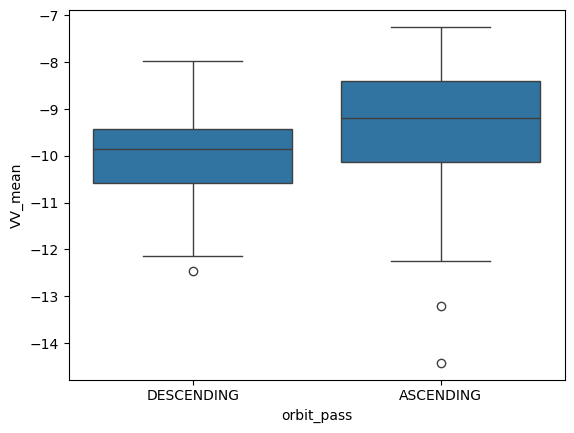

In [22]:
import seaborn as sns

sns.boxplot(x='orbit_pass', y='VV_mean', data=sentinel_1_rain)

<Axes: xlabel='orbit_pass', ylabel='VH_mean'>

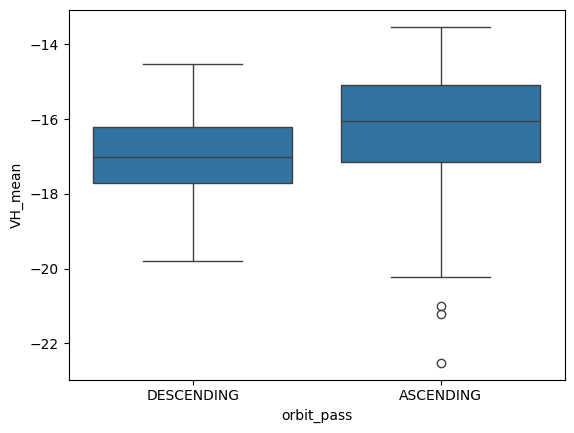

In [23]:
sns.boxplot(x='orbit_pass', y='VH_mean', data=sentinel_1_rain)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10556\3006976654.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


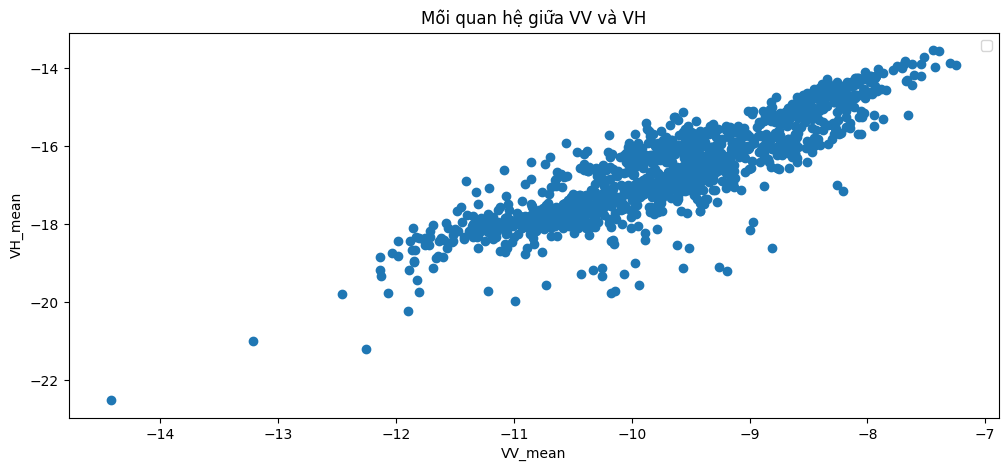

In [24]:
plt.figure(figsize=(12,5))
plt.scatter(sentinel_1_rain['VV_mean'], sentinel_1_rain['VH_mean'])
plt.xlabel('VV_mean')
plt.ylabel('VH_mean')
plt.title('Mỗi quan hệ giữa VV và VH')
plt.legend()
plt.show()

$
    \text{VV increases} \Leftrightarrow \text{VH increases} \\
    \Rightarrow \text{positive correlation} \\
    \text{When wetness increase or the vegetation layer become dense} \Rightarrow \text{Both VV and VH values increase} 
$


$    
    \text{Having some "falling" points get lower values (VH\_mean ≈ -20)}\\
    \text{Having some "falling" points get lower values (VV\_mean ≈ -24)} \\
    \Rightarrow \text{These correspond to big rainfall and flooding}
$

In [25]:
corr = sentinel_1_rain['VV_mean'].corr(sentinel_1_rain['VH_mean'])
print("Hệ số tương quan VV-VH:", corr)


Hệ số tương quan VV-VH: 0.8850361254569026


$
   \text{~ 0.885} \Rightarrow \text{Strong linear relationship}
$

# ***MULIVARIATE ANALYSIS***

In [26]:
print(sentinel_1_rain.columns)

Index(['id', 'date', 'orbit_pass', 'platform', 'DPSVI_mean',
       'Diff_Backscatter_mean', 'ND_VV_VH_mean', 'Prod_Backscatter_mean',
       'RVI_mean', 'Total_Backscatter_mean', 'VH_VV_ratio_mean', 'VH_mean',
       'VV_VH_ratio_mean', 'VV_mean', 'angle_mean', 'precipitation', 'year',
       'month'],
      dtype='object')


In [27]:
from sklearn.preprocessing import LabelEncoder

df_encoded = sentinel_1_rain.copy()
df_encoded['year'] = df_encoded['date'].dt.year
df_encoded['month'] = df_encoded['date'].dt.month
df_encoded['day'] = df_encoded['date'].dt.day
df_encoded.drop(columns=['id', 'date'], inplace=True)

encoder = LabelEncoder()
for col in ['orbit_pass', 'platform']:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()


,orbit_pass,platform,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation,year,month,day
0,1,0,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117,5.097843,2019,1,1
1,1,0,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045,5.097843,2019,1,1
2,1,0,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158,5.097843,2019,1,1
3,0,0,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533,9.548983,2019,1,2
4,0,0,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142,9.548983,2019,1,2


In [28]:
print(df_encoded.columns)

Index(['orbit_pass', 'platform', 'DPSVI_mean', 'Diff_Backscatter_mean',
       'ND_VV_VH_mean', 'Prod_Backscatter_mean', 'RVI_mean',
       'Total_Backscatter_mean', 'VH_VV_ratio_mean', 'VH_mean',
       'VV_VH_ratio_mean', 'VV_mean', 'angle_mean', 'precipitation', 'year',
       'month', 'day'],
      dtype='object')


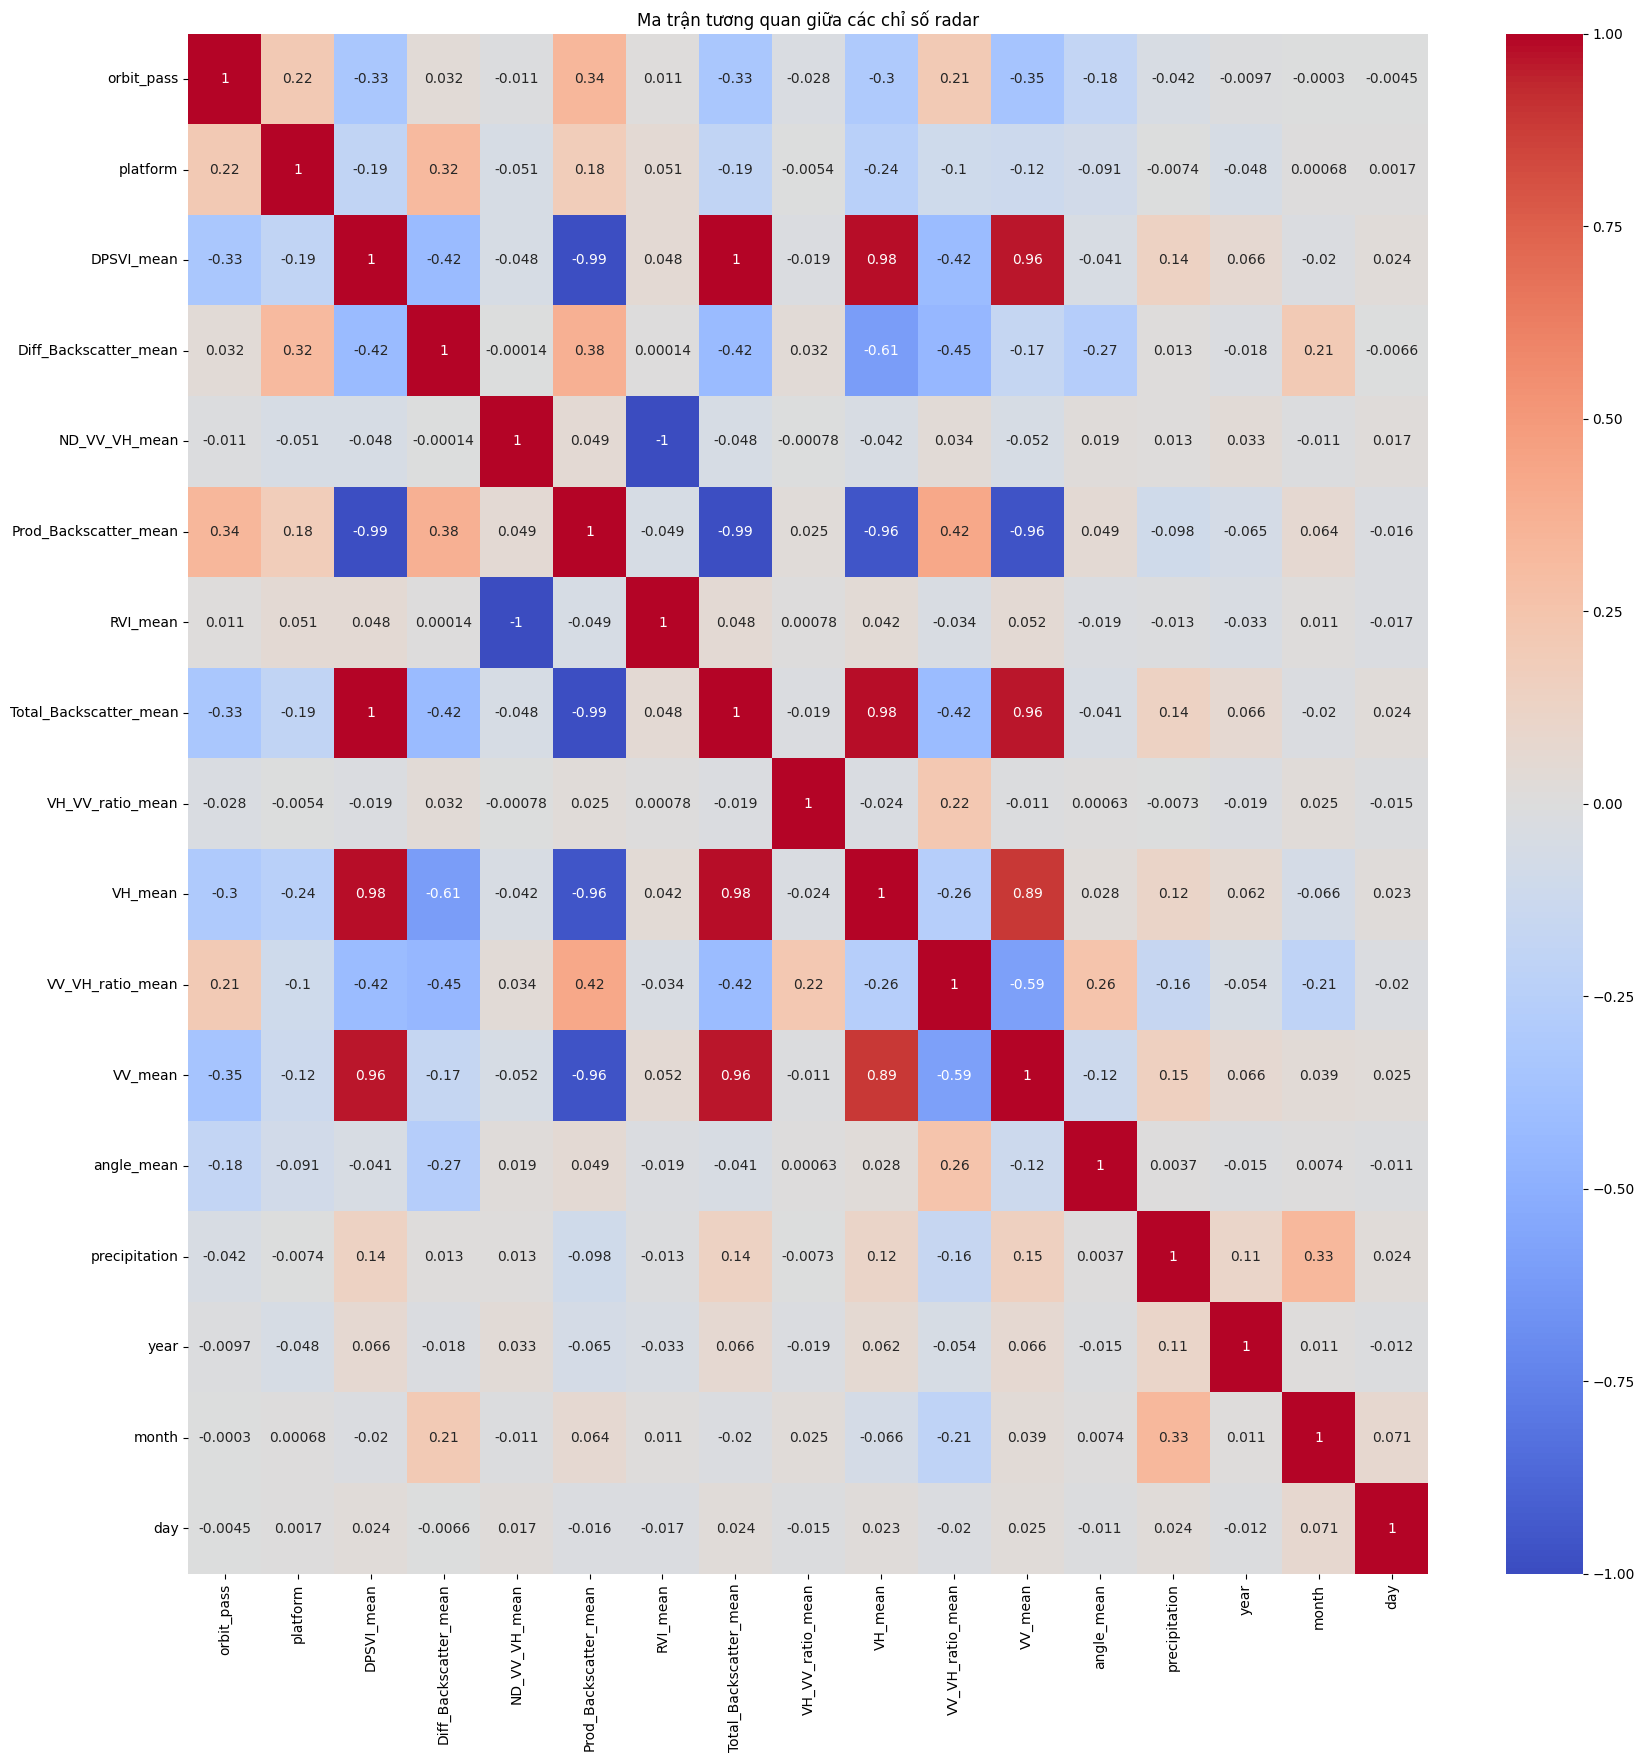

In [29]:
corr = df_encoded.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Ma trận tương quan giữa các chỉ số radar')
plt.show()


Ta thấy rằng month, vv_mean, vv_vh_ratio_mean, vh_mean, total_backscatter_mean và dpsvi_mean ảnh hưởng nhiều đến precipition

In [30]:
climate = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\ProjectCS331\natural\climate\terraclimate_mekong_delta_2019_2024_full.csv")
era5 = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\ProjectCS331\natural\era5\era5_mekong_delta_2019_2024_full.csv")
gldas = pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\ProjectCS331\natural\gldas\gldas_mekong_delta_2019_2024_full.csv")

In [31]:
sentinel_1_rain

,id,date,orbit_pass,platform,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation,year,month
0,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,2019-01-01,DESCENDING,A,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117,5.097843,2019,1
1,S1A_IW_GRDH_1SDV_20190101T224536_20190101T2246...,2019-01-01,DESCENDING,A,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045,5.097843,2019,1
2,S1A_IW_GRDH_1SDV_20190101T224601_20190101T2246...,2019-01-01,DESCENDING,A,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158,5.097843,2019,1
3,S1A_IW_GRDH_1SDV_20190102T111053_20190102T1111...,2019-01-02,ASCENDING,A,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533,9.548983,2019,1
4,S1A_IW_GRDH_1SDV_20190102T111122_20190102T1111...,2019-01-02,ASCENDING,A,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142,9.548983,2019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,S1A_IW_GRDH_1SDV_20211228T224529_20211228T2245...,2021-12-28,DESCENDING,A,-13.262261,7.734260,-0.303824,171.194891,2.607649,-26.524521,1.891253,-17.129390,0.546314,-9.395131,38.105695,0.304541,2021,12
1281,S1A_IW_GRDH_1SDV_20211228T224554_20211228T2246...,2021-12-28,DESCENDING,A,-12.777369,7.573029,-0.306890,157.396961,2.613781,-25.554738,2.121927,-16.563883,0.536995,-8.990854,38.756687,0.304541,2021,12
1282,S1A_IW_GRDH_1SDV_20211228T224619_20211228T2246...,2021-12-28,DESCENDING,A,-13.847672,7.338150,-0.276040,184.714374,2.552080,-27.695344,1.652758,-17.516747,0.569646,-10.178597,41.011031,0.304541,2021,12
1283,S1A_IW_GRDH_1SDV_20211229T111111_20211229T1111...,2021-12-29,ASCENDING,A,-14.028213,7.669149,-0.281880,187.853582,2.563760,-28.056427,1.856888,-17.862788,0.569599,-10.193639,38.569416,0.106470,2021,12


In [32]:
climate

,province,date,aet,def,pdsi,pet,pr,ro,soil,srad,swe,tmmn,tmmx,vap,vpd,vs
0,Soc Trang,2019-01,831.807733,416.877886,2.199813,1248.685618,27.342697,1.450093,1506.560534,184.205915,0.0,24.239529,31.090482,27.448265,1.045621,3.170618
1,Soc Trang,2019-02,576.498879,659.882873,2.601050,1236.381752,0.239447,0.000000,932.963336,218.933719,0.0,24.439559,31.252873,26.868660,1.143835,2.269240
2,Soc Trang,2019-03,351.339839,1065.374654,2.231526,1416.714494,5.381360,0.000000,632.058891,232.650058,0.0,25.642975,32.451756,28.315918,1.274536,1.555077
3,Soc Trang,2019-04,347.554725,1166.472002,1.156982,1514.026728,21.207172,1.035880,485.611935,243.659873,0.0,26.980521,33.982903,29.938434,1.469134,1.841705
4,Soc Trang,2019-05,1419.955006,65.487766,0.556808,1485.442772,152.532443,7.649682,514.075327,223.832794,0.0,26.462267,33.708310,32.415574,1.126596,2.521507
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,Tien Giang,2024-08,1336.336602,71.578267,-3.201277,1407.841969,137.998194,7.004206,2222.744710,239.561432,0.0,25.854493,32.799342,32.932331,0.882634,1.342029
932,Tien Giang,2024-09,1126.928210,0.000000,-2.738077,1126.928210,250.661385,70.347518,2899.417501,176.837699,0.0,25.186377,32.356678,32.812708,0.767901,2.730824
933,Tien Giang,2024-10,1160.281173,0.000000,-2.246379,1160.281173,266.281456,150.213589,2899.911024,191.267867,0.0,25.194867,32.168151,32.106267,0.813151,1.579413
934,Tien Giang,2024-11,965.874174,172.858923,-2.752800,1138.621542,70.514451,3.532463,2602.916727,195.455386,0.0,25.128780,31.966652,30.436846,0.946426,1.661530


In [33]:
era5

,province,date,dewpoint_temperature_2m,dewpoint_temperature_2m_max,dewpoint_temperature_2m_min,evaporation_from_bare_soil_max,evaporation_from_bare_soil_min,evaporation_from_bare_soil_sum,evaporation_from_open_water_surfaces_excluding_oceans_max,evaporation_from_open_water_surfaces_excluding_oceans_min,...,volumetric_soil_water_layer_1_min,volumetric_soil_water_layer_2,volumetric_soil_water_layer_2_max,volumetric_soil_water_layer_2_min,volumetric_soil_water_layer_3,volumetric_soil_water_layer_3_max,volumetric_soil_water_layer_3_min,volumetric_soil_water_layer_4,volumetric_soil_water_layer_4_max,volumetric_soil_water_layer_4_min
0,Soc Trang,2019-01-01,293.075710,294.259993,291.333768,0.000000e+00,-0.000236,-0.001789,0.000000e+00,-0.000034,...,0.415429,0.427620,0.442026,0.424127,0.406290,0.406620,0.406111,0.433936,0.434026,0.433862
1,Soc Trang,2019-01-02,294.158663,295.137745,292.918787,8.829357e-11,-0.000004,-0.000005,3.621012e-07,-0.000008,...,0.422029,0.459457,0.470881,0.446918,0.426396,0.438990,0.406657,0.433929,0.434151,0.433829
2,Soc Trang,2019-01-03,296.340838,297.234004,295.314894,4.930447e-11,-0.000083,-0.000188,3.608253e-07,-0.000103,...,0.420738,0.457295,0.468727,0.452007,0.447296,0.454773,0.439741,0.434790,0.435502,0.434149
3,Soc Trang,2019-01-04,296.701953,297.515055,296.255881,-3.690556e-06,-0.000256,-0.001383,-1.304321e-06,-0.000100,...,0.427495,0.453657,0.462607,0.447592,0.454586,0.455861,0.453107,0.436285,0.436953,0.435571
4,Soc Trang,2019-01-05,296.429946,296.846511,296.059286,-4.550367e-06,-0.000465,-0.003217,-2.975621e-06,-0.000086,...,0.424977,0.440707,0.449445,0.435942,0.452669,0.454528,0.451411,0.437450,0.437855,0.437003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28491,Tien Giang,2024-12-27,297.003963,298.050633,296.133835,0.000000e+00,-0.000392,-0.001938,2.453039e-06,-0.000056,...,0.349100,0.404988,0.442033,0.365309,0.407285,0.410061,0.405915,0.434268,0.434412,0.434172
28492,Tien Giang,2024-12-28,296.439508,297.326576,294.424198,-3.012055e-08,-0.000407,-0.002242,1.294510e-06,-0.000059,...,0.420153,0.433647,0.440515,0.429292,0.409894,0.410836,0.409321,0.434034,0.434164,0.433943
28493,Tien Giang,2024-12-29,294.477852,296.417720,292.609565,-5.915248e-07,-0.000476,-0.002961,-3.070692e-07,-0.000065,...,0.412919,0.426494,0.433813,0.422333,0.410277,0.410867,0.409953,0.433790,0.433937,0.433691
28494,Tien Giang,2024-12-30,294.539371,295.986221,292.512567,-3.068447e-08,-0.000505,-0.003213,-4.108752e-08,-0.000069,...,0.398521,0.415217,0.422124,0.411744,0.409048,0.410158,0.408556,0.433528,0.433686,0.433427


In [34]:
gldas

,province,date,Albedo_inst,AvgSurfT_inst,CanopInt_inst,ECanop_tavg,ESoil_tavg,Evap_tavg,LWdown_f_tavg,Lwnet_tavg,...,SoilMoi10_40cm_inst,SoilMoi40_100cm_inst,SoilTMP0_10cm_inst,SoilTMP100_200cm_inst,SoilTMP10_40cm_inst,SoilTMP40_100cm_inst,Swnet_tavg,Tair_f_inst,Tveg_tavg,Wind_f_inst
0,Soc Trang,2019-01-01,15.064176,296.116210,0.257861,31.123575,48.354889,0.000043,422.840910,-12.606521,...,109.483582,222.052965,296.988799,299.784654,298.973396,299.460783,72.072214,297.177087,29.091923,4.949059
1,Soc Trang,2019-01-02,15.046503,295.184524,0.499870,55.129715,48.429627,0.000041,415.283950,-14.500901,...,119.739326,227.769187,295.883946,299.772967,298.485258,299.381557,85.444306,295.725244,0.000202,6.319528
2,Soc Trang,2019-01-03,15.032153,297.402127,0.492814,66.882153,61.510069,0.000051,406.891451,-34.385217,...,121.098372,238.944090,297.146986,299.756565,298.251014,299.262356,123.494097,298.230100,0.183332,6.701585
3,Soc Trang,2019-01-04,15.017210,298.247638,0.272502,52.087458,71.429661,0.000059,396.353801,-50.506378,...,119.247282,239.034454,298.235860,299.735344,298.403681,299.168705,151.358240,299.458283,25.144652,6.677373
4,Soc Trang,2019-01-05,14.999537,298.353805,0.046923,10.364185,71.103222,0.000057,374.329173,-72.841701,...,115.131874,235.381042,298.508252,299.711972,298.590338,299.120141,203.494508,299.504699,64.742871,5.563865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28491,Tien Giang,2024-12-27,15.461884,298.414364,0.267371,9.445608,34.741659,0.000042,395.986599,-51.564853,...,111.453670,229.843241,298.325947,299.420020,298.344922,298.685934,176.189606,298.750913,62.231150,1.796839
28492,Tien Giang,2024-12-28,15.446581,298.164466,0.131386,30.940173,35.977131,0.000044,397.502117,-49.444631,...,111.681324,229.256001,298.285361,299.393149,298.424294,298.701374,172.542845,298.460651,45.092421,1.660663
28493,Tien Giang,2024-12-29,15.431279,297.559862,0.021048,4.927483,39.688209,0.000048,390.514718,-52.066949,...,110.901991,228.225131,297.728949,299.368493,298.405652,298.715948,184.109206,298.227257,76.720711,1.777112
28494,Tien Giang,2024-12-30,15.415975,297.653504,0.004322,0.481769,38.029398,0.000047,383.035265,-60.584023,...,109.924993,226.866971,297.784292,299.345758,298.362992,298.719640,196.859472,298.361925,80.056696,1.617854


In [ ]:
# # #sentinel_1_rain['date'] = pd.to_datetime(sentinel_1_rain['date']).dt.date
# # climate['date'] = pd.to_datetime(climate['date']).dt.date
# # era5['date'] = pd.to_datetime(era5['date']).dt.date
# # gldas['date'] = pd.to_datetime(gldas['date']).dt.date
# import pandas as pd

# def normalize_date(df):
#     """Chuẩn hóa cột 'date' về datetime.date"""
#     if pd.api.types.is_period_dtype(df['date']):
#         # Period → Timestamp → date
#         df['date'] = df['date'].dt.to_timestamp().dt.date
#     else:
#         # string hoặc datetime → date
#         df['date'] = pd.to_datetime(df['date']).dt.date

# # Áp dụng cho tất cả DataFrame
# for df in [sentinel_1_rain, climate, era5, gldas]:
#     normalize_date(df)


# merged = sentinel_1_rain.merge(climate, on='date', how='left') \
#                         .merge(era5, on='date', how='left') \
#                         .merge(gldas, on='date', how='left')


In [36]:
print(sentinel_1_rain.columns)
print(climate.columns)
print(era5.columns)
print(gldas.columns)


Index(['id', 'date', 'orbit_pass', 'platform', 'DPSVI_mean',
       'Diff_Backscatter_mean', 'ND_VV_VH_mean', 'Prod_Backscatter_mean',
       'RVI_mean', 'Total_Backscatter_mean', 'VH_VV_ratio_mean', 'VH_mean',
       'VV_VH_ratio_mean', 'VV_mean', 'angle_mean', 'precipitation', 'year',
       'month'],
      dtype='object')
Index(['province', 'date', 'aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil',
       'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs'],
      dtype='object')
Index(['province', 'date', 'dewpoint_temperature_2m',
       'dewpoint_temperature_2m_max', 'dewpoint_temperature_2m_min',
       'evaporation_from_bare_soil_max', 'evaporation_from_bare_soil_min',
       'evaporation_from_bare_soil_sum',
       'evaporation_from_open_water_surfaces_excluding_oceans_max',
       'evaporation_from_open_water_surfaces_excluding_oceans_min',
       ...
       'volumetric_soil_water_layer_1_min', 'volumetric_soil_water_layer_2',
       'volumetric_soil_water_layer_2_max',
       'v

In [42]:
climate['ozone'] = 0.03 * climate['tmmx'] + 0.02 * climate['srad'] - 0.01 * climate['vap']

In [47]:
sentinel_1_rain

,id,date,orbit_pass,platform,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation,year,month
0,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,2019-01-01,DESCENDING,A,-12.821056,6.798401,-0.287493,156.491390,2.574986,-25.642111,1.911799,-16.220256,0.585245,-9.421855,37.780117,5.097843,2019,1
1,S1A_IW_GRDH_1SDV_20190101T224536_20190101T2246...,2019-01-01,DESCENDING,A,-12.636335,6.701524,-0.258037,156.336555,2.516074,-25.272670,1.805711,-15.987097,0.574007,-9.285573,38.752045,5.097843,2019,1
2,S1A_IW_GRDH_1SDV_20190101T224601_20190101T2246...,2019-01-01,DESCENDING,A,-13.441704,6.630604,-0.255227,177.196098,2.510454,-26.883407,1.517675,-16.757006,0.598675,-10.126401,41.005158,5.097843,2019,1
3,S1A_IW_GRDH_1SDV_20190102T111053_20190102T1111...,2019-01-01,ASCENDING,A,-13.508179,6.954679,-0.265631,177.711372,2.531262,-27.016357,2.178571,-16.985518,0.586652,-10.030839,38.573533,9.548983,2019,1
4,S1A_IW_GRDH_1SDV_20190102T111122_20190102T1111...,2019-01-01,ASCENDING,A,-12.813217,6.655406,-0.274861,160.166000,2.549723,-25.626434,1.822642,-16.140920,0.581898,-9.485514,40.328142,9.548983,2019,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,S1A_IW_GRDH_1SDV_20211228T224529_20211228T2245...,2021-12-01,DESCENDING,A,-13.262261,7.734260,-0.303824,171.194891,2.607649,-26.524521,1.891253,-17.129390,0.546314,-9.395131,38.105695,0.304541,2021,12
1281,S1A_IW_GRDH_1SDV_20211228T224554_20211228T2246...,2021-12-01,DESCENDING,A,-12.777369,7.573029,-0.306890,157.396961,2.613781,-25.554738,2.121927,-16.563883,0.536995,-8.990854,38.756687,0.304541,2021,12
1282,S1A_IW_GRDH_1SDV_20211228T224619_20211228T2246...,2021-12-01,DESCENDING,A,-13.847672,7.338150,-0.276040,184.714374,2.552080,-27.695344,1.652758,-17.516747,0.569646,-10.178597,41.011031,0.304541,2021,12
1283,S1A_IW_GRDH_1SDV_20211229T111111_20211229T1111...,2021-12-01,ASCENDING,A,-14.028213,7.669149,-0.281880,187.853582,2.563760,-28.056427,1.856888,-17.862788,0.569599,-10.193639,38.569416,0.106470,2021,12


In [51]:
sentinel_avg = (
    sentinel_1_rain.groupby('date', as_index=False)
    .agg({
        'id': 'first',  
        'DPSVI_mean': 'mean',
        'Diff_Backscatter_mean': 'mean',
        'ND_VV_VH_mean': 'mean',
        'Prod_Backscatter_mean': 'mean',
        'RVI_mean': 'mean',
        'Total_Backscatter_mean': 'mean',
        'VH_VV_ratio_mean': 'mean',
        'VH_mean': 'mean',
        'VV_VH_ratio_mean': 'mean',
        'VV_mean': 'mean',
        'angle_mean': 'mean',
        'precipitation': 'mean'
    })
)

sentinel_avg


,date,id,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,VV_VH_ratio_mean,VV_mean,angle_mean,precipitation
0,2019-01-01,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,-12.968502,6.613806,-0.364748,164.336013,2.729496,-25.937003,1.816002,-16.275404,0.587437,-9.661599,40.035604,0.822317
1,2019-02-01,S1B_IW_GRDH_1SDV_20190201T111058_20190201T1111...,-13.169432,6.593215,-0.261269,169.731772,2.522537,-26.338863,1.844174,-16.466039,0.587419,-9.872824,39.892305,0.004701
2,2019-03-01,S1A_IW_GRDH_1SDV_20190302T224509_20190302T2245...,-13.353938,6.836077,-0.267588,174.910912,2.535176,-26.707877,3.099810,-16.771977,0.602236,-9.935900,39.688116,0.142584
3,2019-04-01,S1A_IW_GRDH_1SDV_20190401T111853_20190401T1119...,-13.512460,7.210005,-0.276189,178.559194,2.552378,-27.024921,1.800355,-17.117463,0.571066,-9.907458,40.236058,0.509131
4,2019-05-01,S1A_IW_GRDH_1SDV_20190501T224511_20190501T2245...,-13.122728,6.979682,-0.259899,168.943984,2.519798,-26.245456,1.913851,-16.612569,0.571993,-9.632887,40.036046,4.764124
5,2019-06-01,S1B_IW_GRDH_1SDV_20190601T111100_20190601T1111...,-13.063008,6.851063,-0.281957,168.136260,2.563915,-26.126016,1.822386,-16.488540,0.575571,-9.637476,39.834514,5.631140
6,2019-07-01,S1A_IW_GRDH_1SDV_20190701T111057_20190701T1111...,-12.734804,6.799613,-0.870720,159.090632,3.741440,-25.469608,1.710778,-16.134611,0.569736,-9.334997,40.505099,4.599933
7,2019-08-01,S1A_IW_GRDH_1SDV_20190801T110313_20190801T1103...,-12.508183,6.846960,-0.289889,153.282886,2.579778,-25.016366,1.791043,-15.931663,0.562423,-9.084703,39.650282,8.764154
8,2019-09-01,S1A_IW_GRDH_1SDV_20190903T225349_20190903T2254...,-13.275155,7.106969,-0.277079,179.824315,2.554159,-26.550310,1.824083,-16.828639,0.557686,-9.721671,40.059093,6.228716
9,2019-10-01,S1A_IW_GRDH_1SDV_20191004T224519_20191004T2245...,-13.959790,7.012818,-0.258850,200.569099,2.517701,-27.919580,1.835315,-17.466199,0.583496,-10.453381,39.875614,6.180377


In [49]:
merged = pd.merge(sentinel_avg, climate, on='date', how='inner')

merged.head()

,date,id,DPSVI_mean,Diff_Backscatter_mean,ND_VV_VH_mean,Prod_Backscatter_mean,RVI_mean,Total_Backscatter_mean,VH_VV_ratio_mean,VH_mean,...,ro,soil,srad,swe,tmmn,tmmx,vap,vpd,vs,ozone
0,2019-01-01,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,-12.968502,6.613806,-0.364748,164.336013,2.729496,-25.937003,1.816002,-16.275404,...,1.450093,1506.560534,184.205915,0.0,24.239529,31.090482,27.448265,1.045621,3.170618,4.342350
1,2019-01-01,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,-12.968502,6.613806,-0.364748,164.336013,2.729496,-25.937003,1.816002,-16.275404,...,0.482201,1765.710257,184.265613,0.0,24.051539,30.990707,27.125633,1.048816,3.464843,4.343777
2,2019-01-01,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,-12.968502,6.613806,-0.364748,164.336013,2.729496,-25.937003,1.816002,-16.275404,...,0.412063,2250.003016,190.396916,0.0,23.393985,31.269855,26.710915,1.068595,2.441166,4.478925
3,2019-01-01,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,-12.968502,6.613806,-0.364748,164.336013,2.729496,-25.937003,1.816002,-16.275404,...,2.843047,1125.547834,184.007343,0.0,24.140451,30.864953,27.738312,0.979016,3.054404,4.328712
4,2019-01-01,S1A_IW_GRDH_1SDV_20190101T224511_20190101T2245...,-12.968502,6.613806,-0.364748,164.336013,2.729496,-25.937003,1.816002,-16.275404,...,3.679404,1093.234653,183.210539,0.0,24.033909,30.578831,28.012999,0.905286,3.325427,4.301446


In [ ]:
# def draw_ozone_on_image(image_path, ozone_value, save_path=None):
#     img = Image.open(image_path).convert("RGBA")

#     plt.figure(figsize=(8, 6))
#     plt.imshow(img)
#     plt.axis('off')

#     # Hiển thị chữ ozone
#     plt.text(20, 40, f'Ozone: {ozone_value:.2f}',
#              fontsize=20, color='yellow', weight='bold',
#              bbox=dict(facecolor='black', alpha=0.6))

#     if save_path:
#         plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
#     plt.show()

# image_dir = "images"        
# output_dir = "ozone_overlay"
# os.makedirs(output_dir, exist_ok=True)

# for i, row in merged.iterrows():
#     image_name = f"{row['id']}.png"  # tên ảnh trùng với id
#     image_path = os.path.join(image_dir, image_name)
#     save_path = os.path.join(output_dir, image_name)

#     if os.path.exists(image_path):
#         draw_ozone_on_image(image_path, row['ozone'], save_path)
